# 🏠 House Price Predictor
**Dataset:** Ames Housing Dataset (Kaggle)  
**Goal:** Predict house sale prices using regression models  
**Author:** [Muhammad Ariez]  

---
## 📋 Project Pipeline
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Feature Engineering
4. Model Training & Evaluation
5. Results & Next Steps

---
## 1. ⚙️ Setup & Data Loading
Run the cell below to install and import all required libraries.

In [4]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scikit-learn

# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [5]:
# ── Load the dataset ──────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data
# Place train.csv in the same folder as this notebook (or update the path below)

df = pd.read_csv('train.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.head()

Dataset shape: (1460, 81)
Rows: 1460 | Columns: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 2. 🔍 Exploratory Data Analysis (EDA)
Understand the data before touching it. Answer 3 questions:
- What does the target variable (SalePrice) look like?
- Which features correlate most with SalePrice?
- How much missing data do we have?

In [6]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== Data Types & Non-Null Counts ===')
df.info()

print('\n=== Summary Statistics ===')
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-nu

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


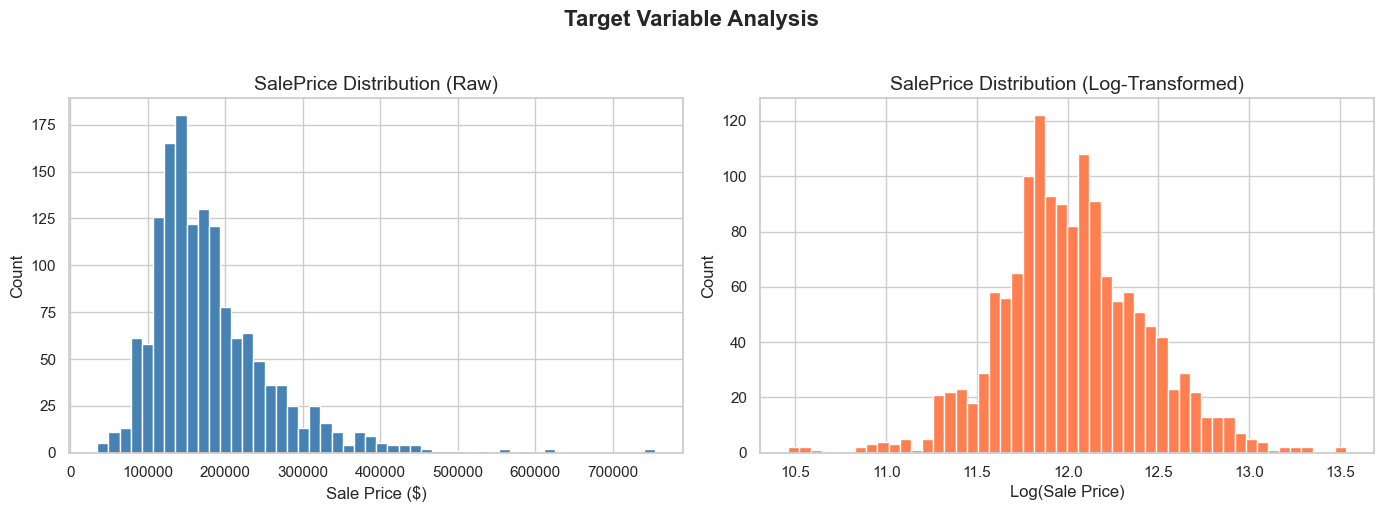

Mean Sale Price:   $180,921
Median Sale Price: $163,000
Skewness:          1.88


In [7]:
# ── Target variable: SalePrice distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Raw)', fontsize=14)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

# Log-transformed (often better for regression)
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log-Transformed)', fontsize=14)
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean Sale Price:   ${df["SalePrice"].mean():,.0f}')
print(f'Median Sale Price: ${df["SalePrice"].median():,.0f}')
print(f'Skewness:          {df["SalePrice"].skew():.2f}')

In [ ]:
# ── Missing values analysis ───────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(f'Columns with missing values: {len(missing_df)}')
print(missing_df.head(20))

# Plot top 20 missing
plt.figure(figsize=(12, 6))
missing_pct.head(20).plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Top 20 Columns by Missing Data %', fontsize=14, fontweight='bold')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Correlation heatmap (numeric features vs SalePrice) ───────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df[numeric_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print('Top 10 positively correlated features:')
print(corr_with_target.head(10))
print('\nTop 10 negatively correlated features:')
print(corr_with_target.tail(10))

# Heatmap of top 15 features
top_features = corr_with_target.abs().nlargest(15).index.tolist() + ['SalePrice']
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[top_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Top 15 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Scatter plots: Top 4 numeric features vs SalePrice ────────────────────────
top4 = corr_with_target.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top4):
    axes[i].scatter(df[feat], df['SalePrice'], alpha=0.4, color='steelblue', edgecolors='none')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

plt.suptitle('Top Features vs Sale Price', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_scatter_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 🛠️ Data Preprocessing & Feature Engineering
Clean the data so models can actually use it.
- Handle missing values
- Encode categorical variables
- Scale numerical features

In [ ]:
# ── Separate features and target ──────────────────────────────────────────────
TARGET = 'SalePrice'
DROP_COLS = ['Id']   # Not useful for prediction

X = df.drop(columns=[TARGET] + DROP_COLS)
y = np.log1p(df[TARGET])   # Log-transform target (reduces skew → better model performance)

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')

In [ ]:
# ── Feature engineering ───────────────────────────────────────────────────────
# Add a couple of useful derived features
X['TotalSF']        = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']   # Total square footage
X['HouseAge']       = X['YrSold'] - X['YearBuilt']                        # Age at time of sale
X['RemodAge']       = X['YrSold'] - X['YearRemodAdd']                     # Years since remodel
X['TotalBathrooms'] = (X['FullBath'] + 0.5 * X['HalfBath'] +
                       X['BsmtFullBath'] + 0.5 * X['BsmtHalfBath'])       # Total bathroom count

print('✅ New features added: TotalSF, HouseAge, RemodAge, TotalBathrooms')

In [ ]:
# ── Handle missing values & encode categoricals ───────────────────────────────
# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns:     {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')

# Fill missing values
X[num_cols] = X[num_cols].fillna(X[num_cols].median())   # Numeric → fill with median
X[cat_cols] = X[cat_cols].fillna('None')                  # Categorical → fill with 'None' (absence of feature)

# Label encode categorical columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(f'\n✅ Missing values handled. Final shape: {X.shape}')
print(f'Remaining nulls: {X.isnull().sum().sum()}')

In [ ]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set:   {X_train.shape}')
print(f'Test set:       {X_test.shape}')

---
## 4. 🤖 Model Training & Evaluation
Train multiple models and compare performance.

**Metrics we care about:**
- **RMSE** (Root Mean Squared Error) — lower is better
- **R² Score** — closer to 1.0 is better (explains % of variance)

In [ ]:
# ── Train multiple models ─────────────────────────────────────────────────────
models = {
    'Linear Regression':          LinearRegression(),
    'Ridge Regression':           Ridge(alpha=10),
    'Lasso Regression':           Lasso(alpha=0.001),
    'Random Forest':              RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':          GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
}

results = {}

for name, model in models.items():
    # Use scaled data for linear models, raw for tree-based
    if 'Regression' in name:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'RMSE': round(rmse, 4), 'R2': round(r2, 4)}
    print(f'{name:<30}  RMSE: {rmse:.4f}  |  R²: {r2:.4f}')

print('\n✅ All models trained!')

In [ ]:
# ── Compare model results ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print('=== Model Comparison (sorted by RMSE) ===')
print(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['RMSE'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('RMSE by Model (lower = better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

results_df['R2'].plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('R² Score by Model (higher = better)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Feature Importance (from best tree-based model) ───────────────────────────
best_model = models['Gradient Boosting']   # Update if a different model won

feat_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
feat_importance.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Top 20 Feature Importances (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Actual vs Predicted plot ──────────────────────────────────────────────────
best_preds = models['Gradient Boosting'].predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.4, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Log(SalePrice)')
plt.ylabel('Predicted Log(SalePrice)')
plt.title('Actual vs Predicted — Gradient Boosting', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. 📝 Results & Next Steps

### Summary
Fill this in after running the notebook:

| Model | RMSE | R² Score |
|---|---|---|
| Linear Regression | TBD | TBD |
| Ridge Regression | TBD | TBD |
| Lasso Regression | TBD | TBD |
| Random Forest | TBD | TBD |
| **Gradient Boosting** | **TBD** | **TBD** |

### Key Findings
- *Which features matter most?*
- *Which model performed best and why?*
- *What surprised you in the EDA?*

### 🚀 Ways to Extend This Project
- [ ] Hyperparameter tuning with `GridSearchCV`
- [ ] Try XGBoost or LightGBM
- [ ] One-hot encode categoricals instead of label encoding
- [ ] Build a Streamlit app to take user inputs and predict live
- [ ] Submit predictions to the Kaggle leaderboard

In [ ]:
# ── Save the best model ───────────────────────────────────────────────────────
import pickle

with open('best_model.pkl', 'wb') as f:
    pickle.dump(models['Gradient Boosting'], f)

print('✅ Model saved as best_model.pkl')
print('   You can load it later with: model = pickle.load(open("best_model.pkl", "rb"))')